In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

## Exploratory Data Analysis

In [4]:
test = pd.read_csv("/Users/jiehni/titanic_survival_analysis/data/test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train = pd.read_csv("/Users/jiehni/titanic_survival_analysis/data/train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Survival by Gender

In [7]:
table = train.groupby("Sex")["Survived"].mean()*100
table = table.round(1).reset_index()
table.columns = ["Gender", "Survival Rate (%)"]
table

,Gender,Survival Rate (%)
0,female,74.2
1,male,18.9


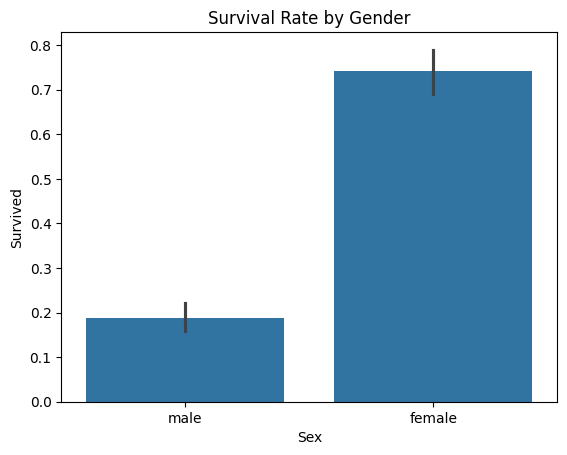

In [8]:
sns.barplot(x="Sex", y="Survived", data=train)
plt.title("Survival Rate by Gender")
plt.show()

Female passengers had a significantly higher survival rate (74.2%) than male passengers (18.9%) which reflects the "women and children first" evacuation policy commonly used in emergency situations.

### Survival by Passenger Class

In [9]:
table = train.groupby("Pclass")["Survived"].mean()*100
table = table.round(1).reset_index()
table.columns = ["Passenger Class", "Survival Rate (%)"]
table

,Passenger Class,Survival Rate (%)
0,1,63.0
1,2,47.3
2,3,24.2


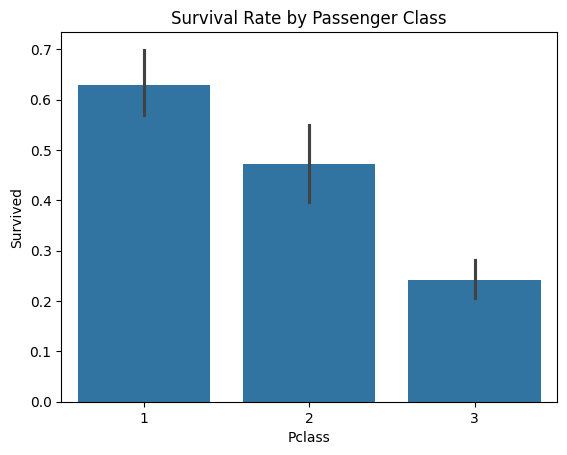

In [10]:
sns.barplot(x="Pclass", y="Survived", data=train)
plt.title("Survival Rate by Passenger Class")
plt.show()

Passenger class has a strong relationship with survival with first class passengers having the highest survival rate (63%), followed by second class passengers (47.3%) while third class passengers had the lowest survival rate (24.2%).

This suggests that socioeconomic status and cabin location likely influenced access to lifeboats, making passenger class an important feature for predicting survival.

### Survival by Age

In [11]:
train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

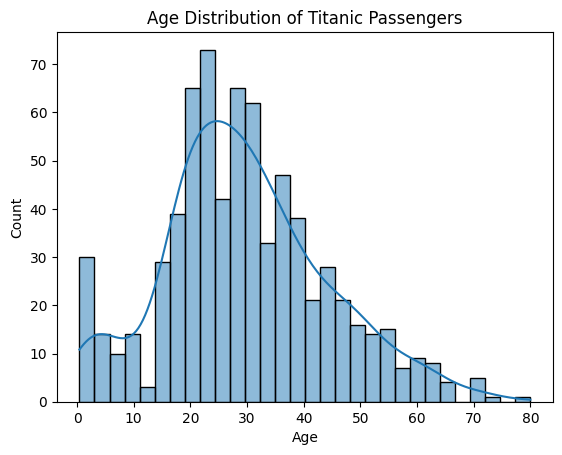

In [12]:
sns.histplot(train["Age"], bins=30, kde=True)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

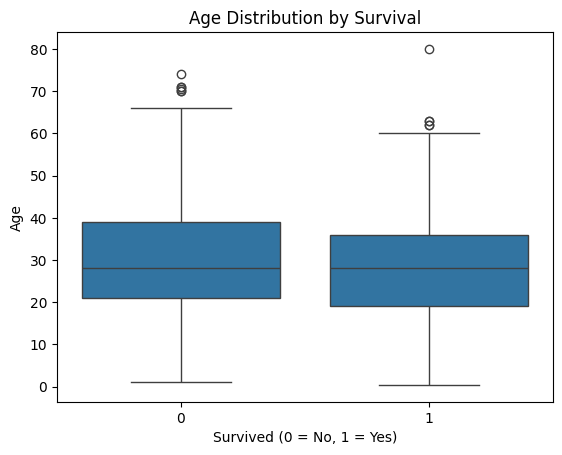

In [13]:
sns.boxplot(x="Survived", y="Age", data=train)
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

The age distributions of survivors and non-survivors appear relatively similar, with both groups having median ages in the late twenties. However, survivors show slightly more younger passengers which may suggest that children had a slightly higher chance of survival.

Overall, age alone does not seem to be a strong predictor of survival.

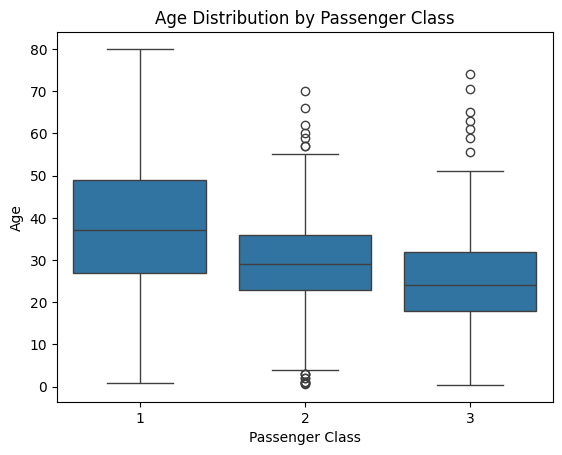

In [14]:
sns.boxplot(x="Pclass", y="Age", data=train)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

First class passengers tend to be older on average than second and third class passengers, while third class passengers show a younger median age and wider spread. This suggests that age and passenger class may interact when predicting survival.